In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

1. LOAD DATA

In [4]:
orders = pd.read_csv("orders.csv")
order_products_prior = pd.read_csv("order_products__prior.csv")

2. MERGE PRIOR ORDER DATA WITH ORDER METADATA

In [8]:
# We use prior orders because they represent past customer behavior
data = order_products_prior.merge(
    orders[["order_id", "user_id", "order_number", "order_hour_of_day", "days_since_prior_order"]],
    on="order_id",
    how="left")

print("Merged data shape:", data.shape)
print(data.head())

Merged data shape: (5998688, 8)
   order_id  product_id  add_to_cart_order  reordered  user_id  order_number  \
0         2       33120                1.0        1.0      NaN           NaN   
1         2       28985                2.0        1.0      NaN           NaN   
2         2        9327                3.0        0.0      NaN           NaN   
3         2       45918                4.0        1.0      NaN           NaN   
4         2       30035                5.0        0.0      NaN           NaN   

   order_hour_of_day  days_since_prior_order  
0                NaN                     NaN  
1                NaN                     NaN  
2                NaN                     NaN  
3                NaN                     NaN  
4                NaN                     NaN  


3. FEATURE ENGINEERING - CUSTOMER LEVEL FEATURES

In [9]:
# 3.1 Total orders, average days between orders, average order hour
customer_features = orders.groupby("user_id").agg(
    total_orders=("order_number", "max"),
    avg_days_between_orders=("days_since_prior_order", "mean"),
    avg_order_hour=("order_hour_of_day", "mean")
).reset_index()

# 3.2 Variance in order number
order_variance = orders.groupby("user_id")["order_number"].var().reset_index()
order_variance.columns = ["user_id", "order_variance"]
customer_features = customer_features.merge(order_variance, on="user_id", how="left")

# 3.3 Average basket size
basket_size = data.groupby(["user_id", "order_id"]).size().reset_index(name="basket_size")
avg_basket_size = basket_size.groupby("user_id")["basket_size"].mean().reset_index()
avg_basket_size.columns = ["user_id", "avg_basket_size"]
customer_features = customer_features.merge(avg_basket_size, on="user_id", how="left")

# 3.4 Reorder rate
reorder_rate = data.groupby("user_id")["reordered"].mean().reset_index()
reorder_rate.columns = ["user_id", "reorder_rate"]
customer_features = customer_features.merge(reorder_rate, on="user_id", how="left")

4. HANDLE MISSING VALUES

In [10]:
customer_features = customer_features.fillna(0)

print("\nCustomer features sample:")
print(customer_features.head())


Customer features sample:
   user_id  total_orders  avg_days_between_orders  avg_order_hour  \
0        1          11.0                19.000000       10.090909   
1        2          15.0                16.285714       10.600000   
2        3          13.0                12.000000       16.307692   
3        4           6.0                17.000000       12.500000   
4        5           5.0                11.500000       15.000000   

   order_variance  avg_basket_size  reorder_rate  
0       11.000000              6.0      0.722222  
1       20.000000              0.0      0.000000  
2       15.166667              7.0      0.571429  
3        3.500000              2.0      0.000000  
4        2.500000             12.0      0.666667  


 5. FEATURE TRANSFORMATION

In [11]:
# Log transform skewed columns
customer_features["total_orders"] = np.log1p(customer_features["total_orders"])
customer_features["avg_basket_size"] = np.log1p(customer_features["avg_basket_size"])


6. PREPARE FEATURE MATRIX

In [12]:
features = customer_features.drop(columns=["user_id"])

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

7. FIND OPTIMAL K USING ELBOW + SILHOUETTE

In [13]:
inertia = []
silhouette_scores = []
K_range = range(2, 10)

sample_n = min(10000, len(customer_features))

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(scaled_features)

    inertia.append(kmeans.inertia_)
    silhouette_scores.append(
        silhouette_score(
            scaled_features,
            labels,
            sample_size=sample_n,
            random_state=42
        )
    )


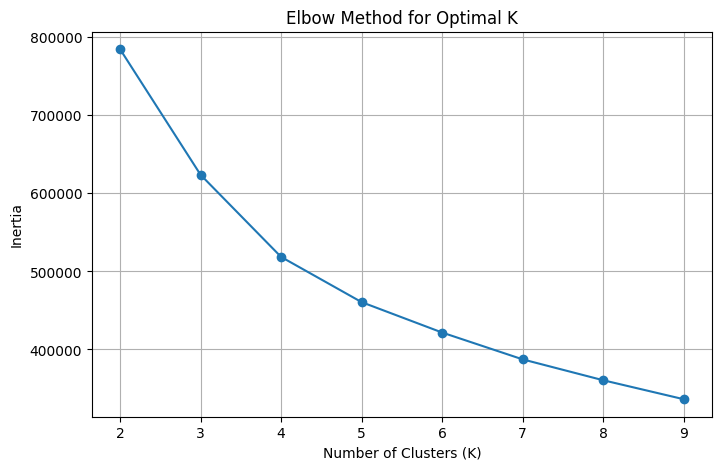

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker="o")
plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.grid(True)
plt.show()


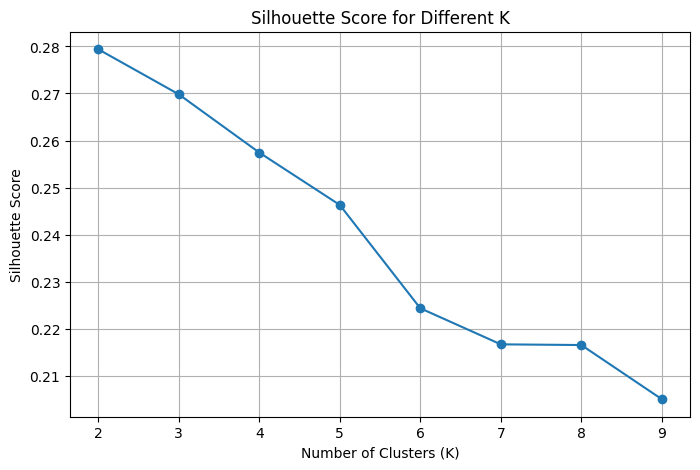


K vs Silhouette Score:
K = 2, Silhouette Score = 0.2794
K = 3, Silhouette Score = 0.2698
K = 4, Silhouette Score = 0.2574
K = 5, Silhouette Score = 0.2463
K = 6, Silhouette Score = 0.2244
K = 7, Silhouette Score = 0.2167
K = 8, Silhouette Score = 0.2165
K = 9, Silhouette Score = 0.2050


In [15]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, silhouette_scores, marker="o")
plt.title("Silhouette Score for Different K")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.grid(True)
plt.show()

# Print scores
print("\nK vs Silhouette Score:")
for k, score in zip(K_range, silhouette_scores):
    print(f"K = {k}, Silhouette Score = {score:.4f}")

8. TRAIN FINAL K-MEANS MODEL


In [21]:
# Change this if plots suggest another K
optimal_k = 4

kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20)
customer_features["cluster"] = kmeans.fit_predict(scaled_features)

# Final silhouette score
final_score = silhouette_score(
    scaled_features,
    customer_features["cluster"],
    sample_size=sample_n,
    random_state=42
)

print(f"\nFinal K-Means model trained with K = {optimal_k}")
print(f"Final Silhouette Score: {final_score:.4f}")


Final K-Means model trained with K = 4
Final Silhouette Score: 0.2574


9. PCA FOR VISUALIZATION

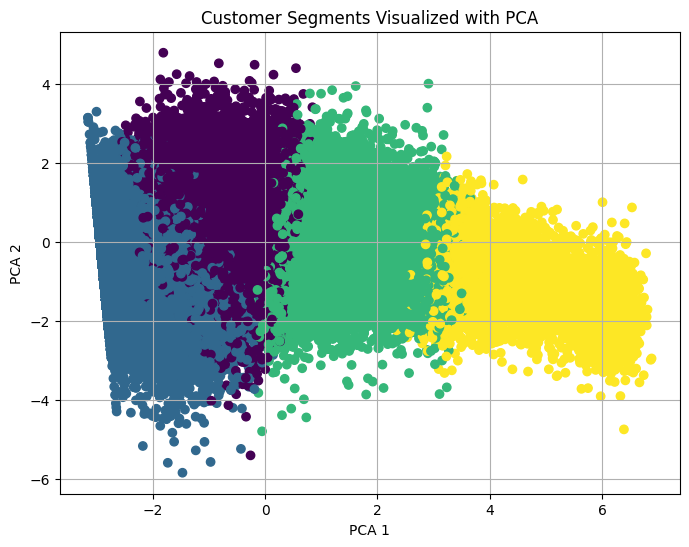

In [22]:
pca = PCA(n_components=2, random_state=42)
pca_features = pca.fit_transform(scaled_features)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_features[:, 0],
    pca_features[:, 1],
    c=customer_features["cluster"]
)
plt.title("Customer Segments Visualized with PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True)
plt.show()


10. CLUSTER PROFILE

In [23]:
cluster_profile = customer_features.drop(columns=["user_id"]).groupby("cluster").mean()

print("\nCluster Profile:")
print(cluster_profile)



Cluster Profile:
         total_orders  avg_days_between_orders  avg_order_hour  \
cluster                                                          
0            2.194653                18.906888       13.834269   
1            1.943512                18.957320       13.613250   
2            3.149192                10.640698       13.344425   
3            4.287329                 4.838990       13.184692   

         order_variance  avg_basket_size  reorder_rate  
cluster                                                 
0              8.124644         2.275446      0.338818  
1              4.774862         0.125720      0.002548  
2             64.368516         2.246798      0.638143  
3            475.150756         2.275425      0.743652  


11. CLUSTER COUNTS

In [24]:
cluster_counts = customer_features["cluster"].value_counts().sort_index()

print("\nCluster Counts:")
print(cluster_counts)



Cluster Counts:
cluster
0    71819
1    43497
2    65141
3     8359
Name: count, dtype: int64


12. SAVE RESULTS

In [25]:
customer_features.to_csv("customer_segmentation_kmeans_results.csv", index=False)
cluster_profile.to_csv("customer_segmentation_kmeans_cluster_profile.csv")

print("\nFiles saved:")
print("- customer_segmentation_kmeans_results.csv")
print("- customer_segmentation_kmeans_cluster_profile.csv")


Files saved:
- customer_segmentation_kmeans_results.csv
- customer_segmentation_kmeans_cluster_profile.csv


Used K-Means clustering to group customers based on how they shop in the Instacart dataset.

Instead of using raw order data, we first summarized each user’s behavior so that each row represents one customer.

Created features that capture shopping habits, like how often a user orders, how big their baskets are, and how likely they are to reorder items.

Applied a log transformation to reduce skew in features like total orders and basket size.

Scaled all features so that no single variable dominates the clustering process.

Tried different values of K and used the elbow method and silhouette score to decide the best number of clusters.
Chose K = 4, which gave a good balance between cluster separation and interpretability.

Trained the final K-Means model and assigned each customer to a cluster.

Looked at the average feature values within each cluster to understand different types of customers.

Used PCA visualization to plot the clusters in 2D and see how well they are separated.